# US Adult Income Dataset - Task 3
Goal: predict whether a person's income is **<=50K** or **>50K** based on their personal information. This is a **binary classification** problem.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

train = pd.read_csv("adult_train.csv")
test = pd.read_csv("adult_test.csv", skiprows=[1])   # first data row in this file is a bad header line

# the test file has a "." at the end of the target values (e.g. "<=50K."), remove it
test["Target"] = test["Target"].str.replace(".", "", regex=False)

df = pd.concat([train, test], ignore_index=True)
df = df.rename(columns={"Target": "Income"})

print(df.shape)
df.head()

(48842, 15)


,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Income
0,39,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             48842 non-null  int64  
 1   Workclass       46043 non-null  str    
 2   fnlwgt          48842 non-null  float64
 3   Education       48842 non-null  str    
 4   Education_Num   48842 non-null  float64
 5   Martial_Status  48842 non-null  str    
 6   Occupation      46033 non-null  str    
 7   Relationship    48842 non-null  str    
 8   Race            48842 non-null  str    
 9   Sex             48842 non-null  str    
 10  Capital_Gain    48842 non-null  float64
 11  Capital_Loss    48842 non-null  float64
 12  Hours_per_week  48842 non-null  float64
 13  Country         47985 non-null  str    
 14  Income          48842 non-null  str    
dtypes: float64(5), int64(1), str(9)
memory usage: 5.6 MB


## 2. EDA (Exploratory Data Analysis)

### 2.1 Class balance

In [3]:
df["Income"].value_counts()

Income
<=50K    37155
>50K     11687
Name: count, dtype: int64

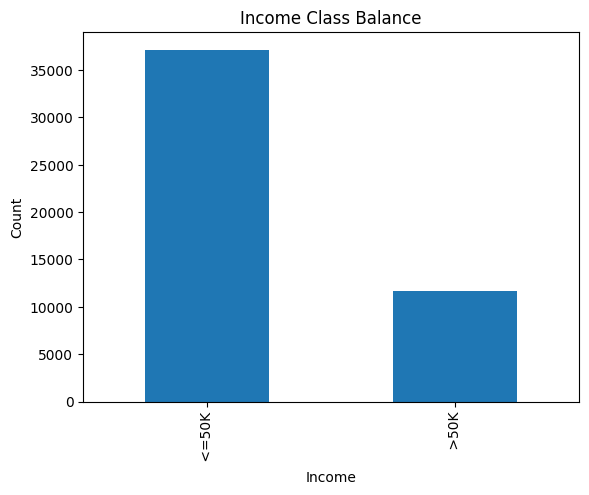

In [4]:
df["Income"].value_counts().plot(kind="bar")
plt.title("Income Class Balance")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

The classes are not balanced: there are a lot more people earning `<=50K` than `>50K`. We deal with this later in the **Handle Imbalance** step.

### 2.2 Numerical features

In [5]:
df.describe()

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### 2.3 Categorical features

In [6]:
categorical_cols = ["Workclass", "Education", "Martial_Status", "Occupation",
                    "Relationship", "Race", "Sex", "Country"]

for col in categorical_cols:
    print(col, "->", df[col].nunique(), "unique values")

Workclass

 -> 8 unique values
Education -> 16 unique values
Martial_Status -> 7 unique values
Occupation -> 14 unique values
Relationship -> 6 unique values
Race -> 5 unique values
Sex -> 2 unique values
Country -> 41 unique values


### 2.4 Visualize key relationships

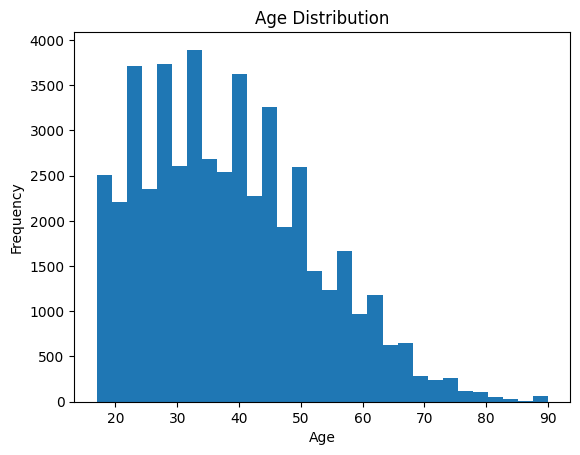

In [7]:
plt.hist(df["Age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

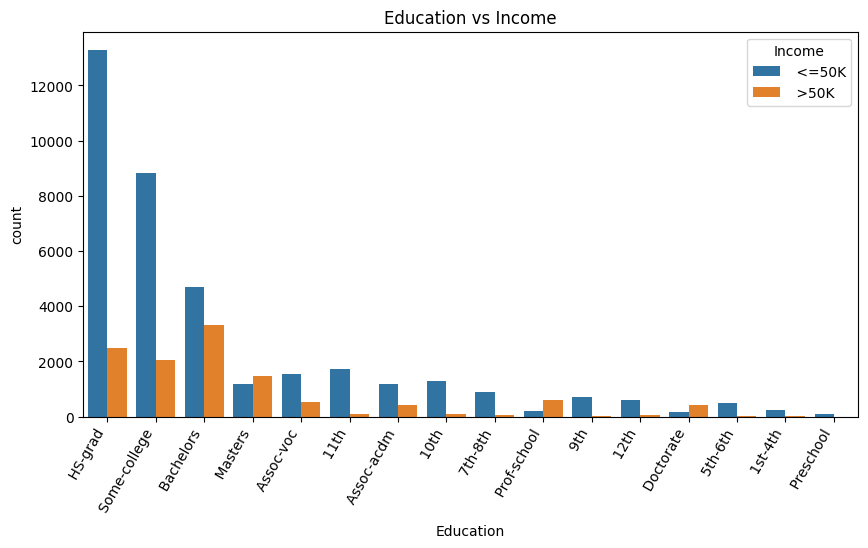

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(x="Education", hue="Income", data=df,
              order=df["Education"].value_counts().index)
plt.title("Education vs Income")
plt.xticks(rotation=60, ha="right")
plt.show()

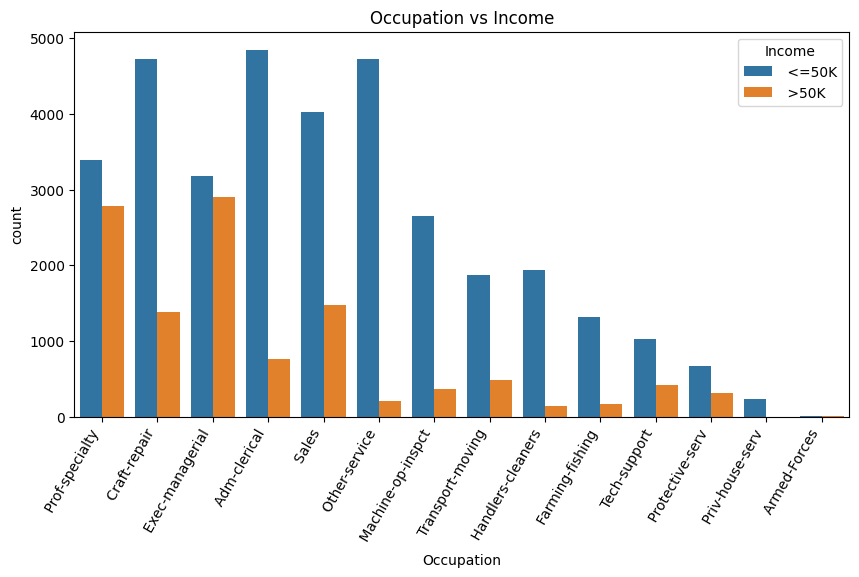

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(x="Occupation", hue="Income", data=df,
              order=df["Occupation"].value_counts().index)
plt.title("Occupation vs Income")
plt.xticks(rotation=60, ha="right")
plt.show()

## 3. Data Cleaning

### 3.1 Handle missing values
First we clean the text columns (remove extra spaces), then check for missing values and drop the rows that have them (they are a small percentage of the data).

In [10]:
object_cols = df.select_dtypes(include="object").columns
for col in object_cols:
    df[col] = df[col].str.strip()

print(df.isnull().sum())

Age                  0
Workclass         2799
fnlwgt               0
Education            0
Education_Num        0
Martial_Status       0
Occupation        2809
Relationship         0
Race                 0
Sex                  0
Capital_Gain         0
Capital_Loss         0
Hours_per_week       0
Country            857
Income               0
dtype: int64


/tmp/ipykernel_492/1509634899.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [11]:
print("Rows before dropping missing values:", df.shape[0])
df = df.dropna()
print("Rows after dropping missing values:", df.shape[0])

Rows before dropping missing values: 48842
Rows after dropping missing values: 45222


### 3.2 Remove duplicate rows

In [12]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 47
Shape after removing duplicates: (45175, 15)


## 4. Feature Engineering

### 4.1 Create new features
We turn `Age` and `Hours_per_week` into simple groups, which can make patterns easier for some models to pick up.

In [13]:
df["Age_Group"] = pd.cut(df["Age"], bins=[0, 25, 40, 60, 100],
                          labels=["Young", "Adult", "Middle_Aged", "Senior"])

df["Work_Hours_Group"] = pd.cut(df["Hours_per_week"], bins=[0, 35, 45, 100],
                                 labels=["Part_Time", "Full_Time", "Over_Time"])

df[["Age", "Age_Group", "Hours_per_week", "Work_Hours_Group"]].head()

,Age,Age_Group,Hours_per_week,Work_Hours_Group
0,39,Adult,40.0,Full_Time
1,50,Middle_Aged,13.0,Part_Time
2,38,Adult,40.0,Full_Time
3,53,Middle_Aged,40.0,Full_Time
4,28,Adult,40.0,Full_Time


### 4.2 Encode the target

In [14]:
df["Income"] = df["Income"].map({"<=50K": 0, ">50K": 1})
df["Income"].value_counts()

Income
0    33973
1    11202
Name: count, dtype: int64

### 4.3 Encode categorical features
`Sex` only has two values, so we use Label Encoding (0/1). All the other categorical columns have more than two categories with no natural order, so we use One-Hot Encoding.

In [15]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

df = pd.get_dummies(df, columns=["Workclass", "Education", "Martial_Status", "Occupation",
                                  "Relationship", "Race", "Country",
                                  "Age_Group", "Work_Hours_Group"])

print(df.shape)
df.head()

(45175, 111)


,Age,fnlwgt,Education_Num,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Income,Workclass_Federal-gov,Workclass_Local-gov,...,Country_United-States,Country_Vietnam,Country_Yugoslavia,Age_Group_Young,Age_Group_Adult,Age_Group_Middle_Aged,Age_Group_Senior,Work_Hours_Group_Part_Time,Work_Hours_Group_Full_Time,Work_Hours_Group_Over_Time
0,39,77516.0,13.0,1,2174.0,0.0,40.0,0,False,False,...,True,False,False,False,True,False,False,False,True,False
1,50,83311.0,13.0,1,0.0,0.0,13.0,0,False,False,...,True,False,False,False,False,True,False,True,False,False
2,38,215646.0,9.0,1,0.0,0.0,40.0,0,False,False,...,True,False,False,False,True,False,False,False,True,False
3,53,234721.0,7.0,1,0.0,0.0,40.0,0,False,False,...,True,False,False,False,False,True,False,False,True,False
4,28,338409.0,13.0,0,0.0,0.0,40.0,0,False,False,...,False,False,False,False,True,False,False,False,True,False


## 5. Handle Imbalance
The two classes are not equal (about 76% vs 24%). Instead of adding an extra library like SMOTE, we use `class_weight="balanced"` in the models that support it — this simply makes the model pay more attention to the smaller class (`>50K`) during training.

In [16]:
df["Income"].value_counts(normalize=True) * 100

Income
0    75.203099
1    24.796901
Name: proportion, dtype: float64

## 6. Feature Selection

### 6.1 Correlation

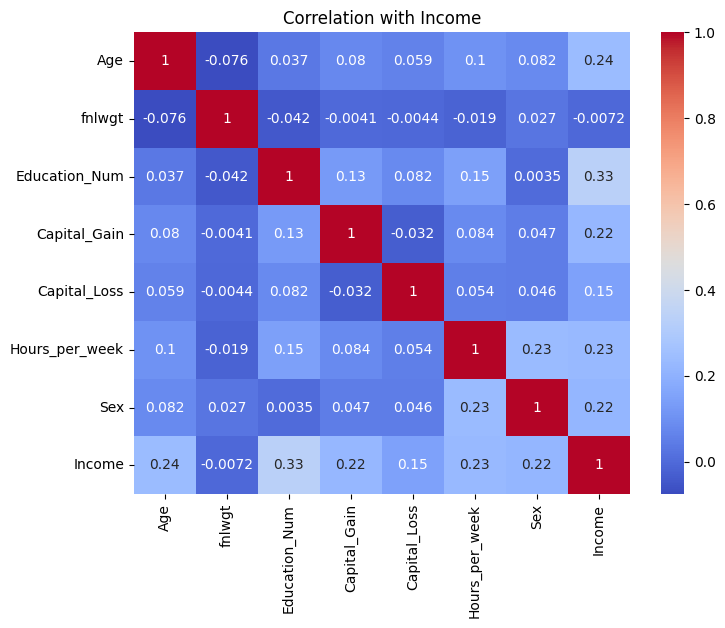

In [17]:
numeric_cols = ["Age", "fnlwgt", "Education_Num", "Capital_Gain",
                "Capital_Loss", "Hours_per_week", "Sex", "Income"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation with Income")
plt.show()

### 6.2 Feature importance (from a Random Forest)

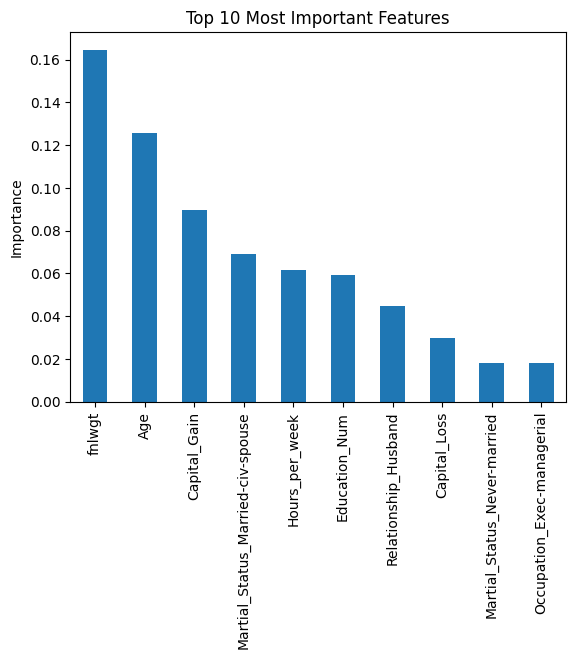

In [18]:
X_all = df.drop("Income", axis=1)
y_all = df["Income"]

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_all, y_all)

importances = pd.Series(rf_selector.feature_importances_, index=X_all.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Most Important Features")
plt.ylabel("Importance")
plt.show()

### 6.3 RFE (Recursive Feature Elimination)
RFE is slow on many columns, so here we demonstrate it on the numerical features only, selecting the best 4 out of 6.

In [19]:
num_features = ["Age", "fnlwgt", "Education_Num", "Capital_Gain", "Capital_Loss", "Hours_per_week"]

rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=4)
rfe.fit(df[num_features], df["Income"])

selected = [f for f, keep in zip(num_features, rfe.support_) if keep]
print("Features selected by RFE:", selected)

Features selected by RFE: ['Age', 'Education_Num', 'Capital_Loss', 'Hours_per_week']


## 7. Train / Test Split and Scaling

In [20]:
X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (36140, 110)
Test size: (9035, 110)


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Model Training
We train several models and compare them: Logistic Regression, Naive Bayes, Decision Tree, Random Forest, SVM, and KNN.

In [22]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

In [23]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

In [24]:
tree_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [25]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [26]:
svm_model = LinearSVC(class_weight="balanced", max_iter=5000, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

In [27]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

## 9. Evaluation

In [28]:
results = {
    "Logistic Regression": y_pred_log,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn
}

for name, y_pred in results.items():
    print(name)
    print("  Accuracy :", accuracy_score(y_test, y_pred))
    print("  Precision:", precision_score(y_test, y_pred))
    print("  Recall   :", recall_score(y_test, y_pred))
    print("  F1 Score :", f1_score(y_test, y_pred))
    print()

Logistic Regression
  Accuracy : 0.810403984504704
  Precision: 0.5813020672631903
  Recall   : 0.8410714285714286
  F1 Score : 0.6874657909140668

Naive Bayes
  Accuracy : 0.6099612617598229
  Precision: 0.38220183486238535
  Recall   : 0.9299107142857143
  F1 Score : 0.541742522756827

Decision Tree
  Accuracy : 0.8102933038184836
  Precision: 0.617831541218638
  Recall   : 0.615625
  F1 Score : 0.6167262969588551

Random Forest
  Accuracy : 0.8459324847814056
  Precision: 0.7294372294372294
  Recall   : 0.6017857142857143
  F1 Score : 0.6594911937377691

SVM
  Accuracy : 0.8071942446043165
  Precision: 0.5752720677146312
  Recall   : 0.8495535714285715
  F1 Score : 0.6860129776496035

KNN
  Accuracy : 0.8164914222468179
  Precision: 0.6556149732620321
  Recall   : 0.5473214285714286
  F1 Score : 0.5965936739659368



In [29]:
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [accuracy_score(y_test, p) for p in results.values()],
    "Precision": [precision_score(y_test, p) for p in results.values()],
    "Recall": [recall_score(y_test, p) for p in results.values()],
    "F1 Score": [f1_score(y_test, p) for p in results.values()]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810404,0.581302,0.841071,0.687466
1,Naive Bayes,0.609961,0.382202,0.929911,0.541743
2,Decision Tree,0.810293,0.617832,0.615625,0.616726
3,Random Forest,0.845932,0.729437,0.601786,0.659491
4,SVM,0.807194,0.575272,0.849554,0.686013
5,KNN,0.816491,0.655615,0.547321,0.596594


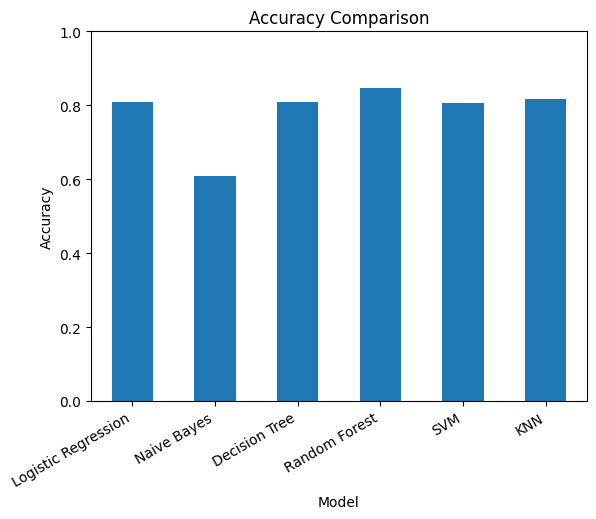

In [30]:
comparison.set_index("Model")["Accuracy"].plot(kind="bar")
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.show()

## 10. Tuning
As an example, we tune Logistic Regression's `C` parameter with Grid Search.

In [31]:
param_grid = {"C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight="balanced"),
                     param_grid, cv=3, scoring="f1")
grid.fit(X_train_scaled, y_train)

print("Best C:", grid.best_params_)
print("Best F1 score (cross-validation):", grid.best_score_)

Best C: {'C': 1}
Best F1 score (cross-validation): 0.6931857690006438


## 11. Validation (Cross-Validation)

In [32]:
cv_scores = cross_val_score(LogisticRegression(max_iter=1000, class_weight="balanced"),
                             X_train_scaled, y_train, cv=5, scoring="accuracy")

print("Cross-validation accuracy scores:", cv_scores)
print("Average accuracy:", cv_scores.mean())

Cross-validation accuracy scores: [0.81198118 0.80672385 0.81889873 0.80866076 0.82138904]
Average accuracy: 0.8135307138904262


## 12. Interpretation
We already saw the most important features from the Random Forest in section 6.2 — `Capital_Gain`, `Education_Num`, `Age`, `Hours_per_week` and marital status tend to matter the most for predicting income. A deeper tool like SHAP could explain individual predictions, but it's left out here to keep the notebook simple.

## 13. Deployment (Optional)
We save the best-performing model to a file so it can be reused later without retraining.

In [33]:
import joblib

joblib.dump(rf_model, "income_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved.")

Model and scaler saved.
